In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import scipy.cluster.hierarchy as sch

# Load Data
df = pd.read_csv('adult_dataset.csv')
df = df.drop('income', axis=1)
#df_clustering=df.copy()
df


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39.0,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36.0,United-States
48838,64.0,NaN,321403,HS-grad,9,Widowed,NaN,Other-relative,Black,Male,0,0,40.0,United-States
48839,38.0,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50.0,United-States
48840,44.0,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40.0,United-States


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             46400 non-null  float64
 1   workclass       45480 non-null  object 
 2   fnlwgt          48842 non-null  int64  
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  int64  
 5   marital-status  48842 non-null  object 
 6   occupation      45485 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital-gain    48842 non-null  int64  
 11  capital-loss    48842 non-null  int64  
 12  hours-per-week  46400 non-null  float64
 13  native-country  46137 non-null  object 
dtypes: float64(2), int64(4), object(8)
memory usage: 5.2+ MB


In [19]:
df.duplicated().sum()

np.int64(26)

In [20]:
df=df.drop_duplicates()

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df.isna().sum().sum()

np.int64(14308)

In [23]:

round(df.isnull().mean()*100,2)

,0
age,5.00
workclass,6.89
fnlwgt,0.00
education,0.00
education-num,0.00
marital-status,0.00
occupation,6.88
relationship,0.00
race,0.00
sex,0.00


In [24]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country'],
      dtype='object')

In [25]:
cat_cols = df.select_dtypes(include="object").columns.tolist()
cat_cols

['workclass',
 'education',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native-country']

In [26]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
num_cols

['age',
 'fnlwgt',
 'education-num',
 'capital-gain',
 'capital-loss',
 'hours-per-week']

In [27]:
# 1. Preprocessing
df.replace('?', np.nan, inplace=True)
df.isna().sum()

/tmp/ipython-input-360596525.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.replace('?', np.nan, inplace=True)


,0
age,2442
workclass,5125
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,5115
relationship,0
race,0
sex,0


In [28]:
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    df[col].fillna(df[col].median(), inplace=True)
for col in df.select_dtypes(include=['object']).columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

df.isnull().sum()

/tmp/ipython-input-396041143.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipython-input-396041143.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipython-input-396041143.py:4: FutureWarning: A value is trying to be set on a copy o

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [29]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48816.000000,4.881600e+04,48816.000000,48816.000000,48816.000000,48816.000000
mean,38.599517,1.896563e+05,10.078519,1079.642351,87.548918,40.428958
std,13.602565,1.056087e+05,2.570374,7453.961730,403.106802,12.326844
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175490e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781350e+05,10.000000,0.000000,0.000000,40.000000
75%,47.000000,2.376028e+05,12.000000,0.000000,0.000000,45.000000
max,255.000000,1.490400e+06,16.000000,99999.000000,4356.000000,250.000000


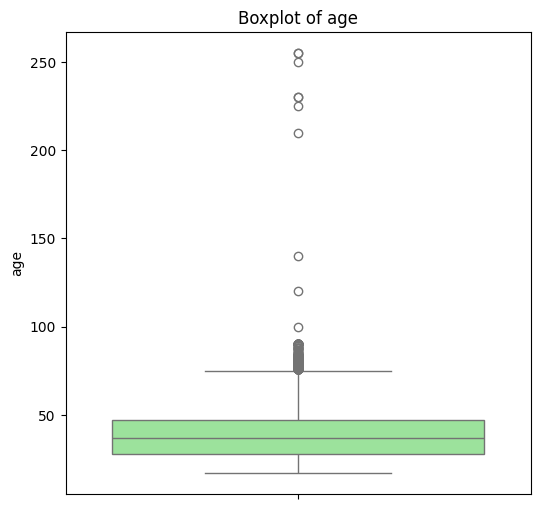

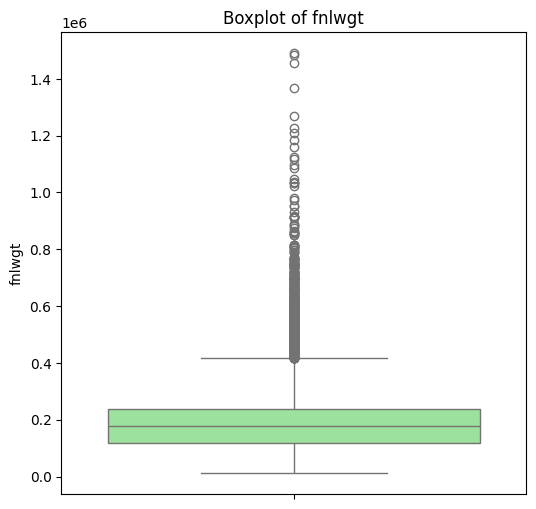

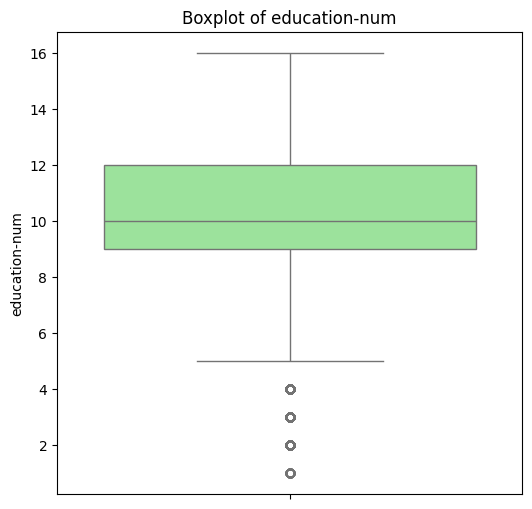

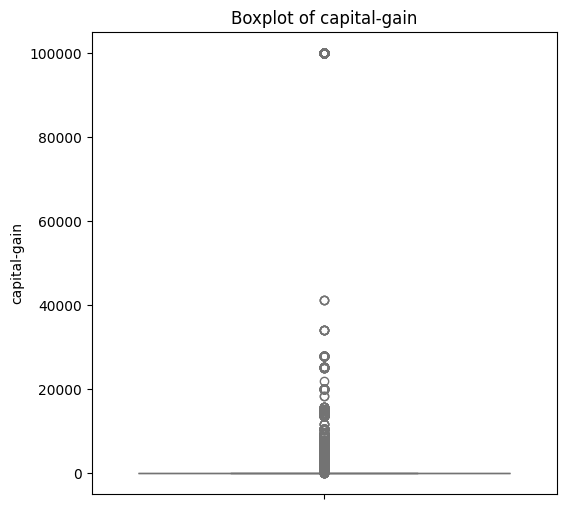

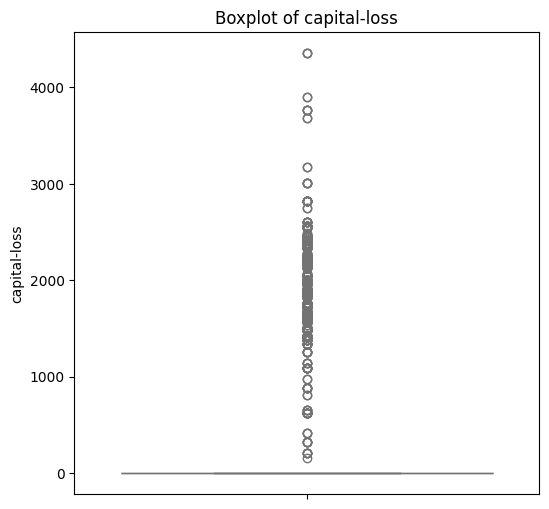

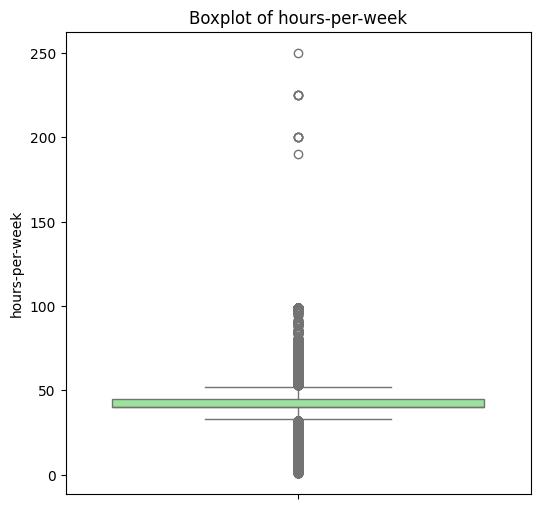

In [30]:
# Boxplots (to check outliers)
for col in num_cols:
    plt.figure(figsize=(6,6))
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(f'Boxplot of {col}')
    plt.show()

In [31]:
df.select_dtypes("number").skew()

,0
age,1.017849
fnlwgt,1.439469
education-num,-0.315212
capital-gain,11.891462
capital-loss,4.568423
hours-per-week,0.812916


In [32]:
# Check if 'capital-gain' and 'capital-loss' columns exist before processing
if 'capital-gain' in df.columns and 'capital-loss' in df.columns:
    df['log_capital-gain'] = np.log1p(df['capital-gain'])
    df['log_capital-loss'] = np.log1p(df['capital-loss'])

    # It's good practice to print skewness if it's part of the analysis
    # print(f"Skewness of log_capital-gain: {df['log_capital-gain'].skew()}")
    # print(f"Skewness of log_capital-loss: {df['log_capital-loss'].skew()}")

    # Drop original columns after creating log-transformed ones
    df.drop(['capital-gain', 'capital-loss'], axis=1, inplace=True)
    print("Capital gain and loss columns transformed to log scale and original columns dropped.")
elif 'log_capital-gain' in df.columns and 'log_capital-loss' in df.columns:
    print("Log-transformed capital gain and loss columns already exist, skipping transformation.")
else:
    print("Original capital gain and loss columns not found, and log-transformed columns not present either. Please ensure DataFrame state is correct.")

df_clustering = df.copy()

Capital gain and loss columns transformed to log scale and original columns dropped.


/tmp/ipython-input-3656064163.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['log_capital-gain'] = np.log1p(df['capital-gain'])
/tmp/ipython-input-3656064163.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['log_capital-loss'] = np.log1p(df['capital-loss'])
/tmp/ipython-input-3656064163.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#ret

In [33]:


# Outlier treatment (IQR)
def treat_outliers(df, col):
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = np.clip(df[col], Q1 - 1.5*IQR, Q3 + 1.5*IQR)
    return df

for col in ['age', 'fnlwgt', 'education-num',  'hours-per-week']:
    df = treat_outliers(df, col)
df.describe()


/tmp/ipython-input-2527802609.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = np.clip(df[col], Q1 - 1.5*IQR, Q3 + 1.5*IQR)
/tmp/ipython-input-2527802609.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = np.clip(df[col], Q1 - 1.5*IQR, Q3 + 1.5*IQR)
/tmp/ipython-input-2527802609.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.

,age,fnlwgt,education-num,hours-per-week,log_capital-gain,log_capital-loss
count,48816.000000,48816.000000,48816.000000,48816.000000,48816.000000,48816.000000
mean,38.536003,186758.463206,10.122357,41.130879,0.728932,0.351160
std,13.269918,95320.827139,2.456716,6.033878,2.446073,1.586634
min,17.000000,12285.000000,4.500000,32.500000,0.000000,0.000000
25%,28.000000,117549.000000,9.000000,40.000000,0.000000,0.000000
50%,37.000000,178135.000000,10.000000,40.000000,0.000000,0.000000
75%,47.000000,237602.750000,12.000000,45.000000,0.000000,0.000000
max,75.500000,417683.375000,16.000000,52.500000,11.512925,8.379539


In [34]:
df.select_dtypes("number").skew()

,0
age,0.530028
fnlwgt,0.555044
education-num,-0.035143
hours-per-week,0.480306
log_capital-gain,3.112560
log_capital-loss,4.301635


In [35]:
cat_cols1 = df.select_dtypes(include="object").columns.tolist()
cat_cols1
num_cols1 = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
num_cols1

['age',
 'fnlwgt',
 'education-num',
 'hours-per-week',
 'log_capital-gain',
 'log_capital-loss']

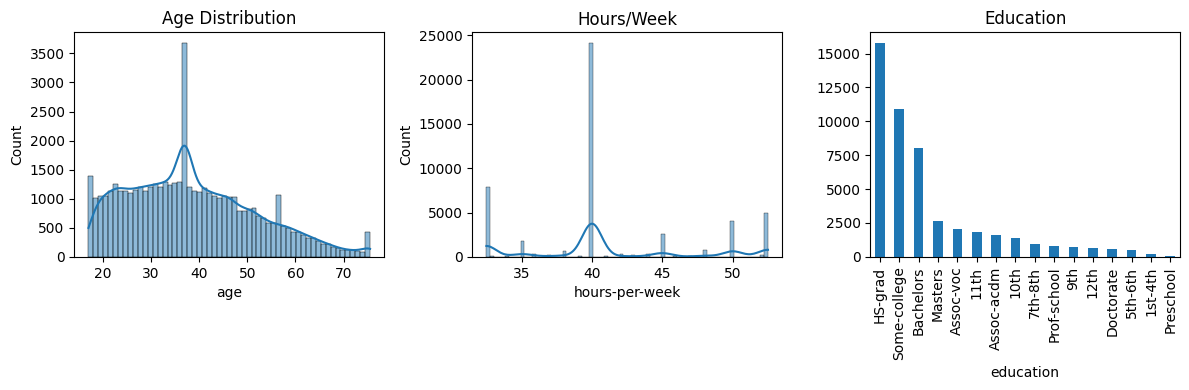

In [36]:
# --- EXPLORATORY DATA ANALYSIS (EDA) ---
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); sns.histplot(df['age'], kde=True); plt.title('Age Distribution')
plt.subplot(1, 3, 2); sns.histplot(df['hours-per-week'], kde=True); plt.title('Hours/Week')
plt.subplot(1, 3, 3); df['education'].value_counts().plot(kind='bar'); plt.title('Education')
plt.tight_layout()
plt.show()

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
# Encoding & Scaling

preprocess = ColumnTransformer([
    #df_clustering = df.drop('income', axis=1)
    ('num', StandardScaler(), num_cols1),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols1)
])

#Generate the scaled numerical matrix
X_scaled = preprocess.fit_transform(df_clustering)



/tmp/ipython-input-2569778271.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x=df['age'], y=df['hours-per-week'],palette='summer')


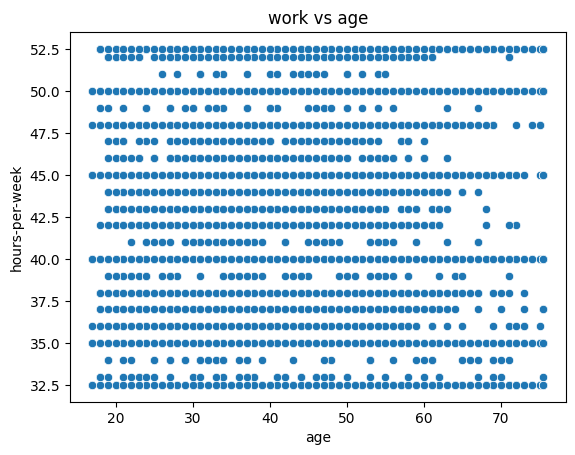

In [38]:
sns.scatterplot(x=df['age'], y=df['hours-per-week'],palette='summer')
plt.title('work vs age')
plt.show()

In [39]:
from sklearn.cluster import KMeans
#from sklearn.metrics import silhouette_score
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

/tmp/ipython-input-911262662.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Cluster'] = kmeans.fit_predict(X_scaled)


In [40]:
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,hours-per-week,native-country,log_capital-gain,log_capital-loss,Cluster
0,39.0,State-gov,77516.0,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,40.0,United-States,7.684784,0.0,0
1,50.0,Self-emp-not-inc,83311.0,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,32.5,United-States,0.000000,0.0,0
2,38.0,Private,215646.0,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,40.0,United-States,0.000000,0.0,2
3,53.0,Private,234721.0,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,40.0,United-States,0.000000,0.0,0
4,28.0,Private,338409.0,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,40.0,Cuba,0.000000,0.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39.0,Private,215419.0,Bachelors,13.0,Divorced,Prof-specialty,Not-in-family,White,Female,36.0,United-States,0.000000,0.0,2
48838,64.0,Private,321403.0,HS-grad,9.0,Widowed,Prof-specialty,Other-relative,Black,Male,40.0,United-States,0.000000,0.0,0
48839,38.0,Private,374983.0,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Husband,White,Male,50.0,United-States,0.000000,0.0,0
48840,44.0,Private,83891.0,Bachelors,13.0,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,40.0,United-States,8.604471,0.0,0


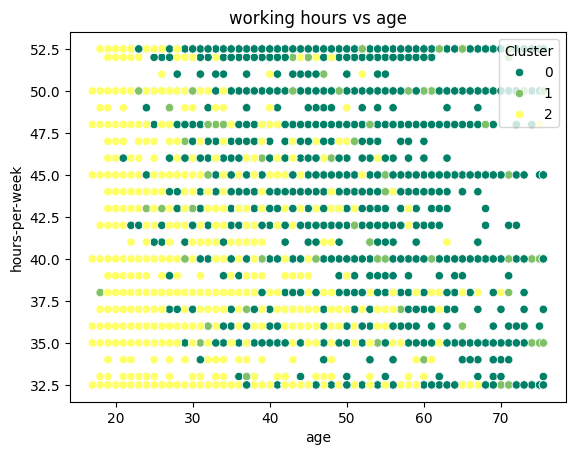

In [41]:
sns.scatterplot(x=df['age'], y=df['hours-per-week'],hue=df['Cluster'],palette='summer')
plt.title('working hours vs age')
plt.show()

Elbow method

In [42]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(X_scaled)

In [43]:
inertia=[]
kvalue=range(1,11)
for k in kvalue:
    kmeans=KMeans(n_clusters=k)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

In [44]:
kvalue

range(1, 11)

In [45]:
inertia

[5125680.000000444,
 4937906.727880027,
 4981347.286269681,
 4920491.840416803,
 4746930.925782189,
 4696681.647282774,
 4627903.113512169,
 4586643.6289439695,
 4561946.441891352,
 4518244.199832683]

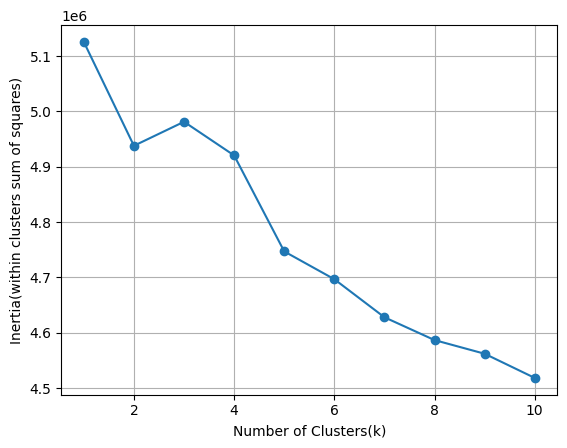

In [72]:
import matplotlib.pyplot as plt
plt.plot(kvalue,inertia,'o-')
plt.xlabel('Number of Clusters(k)')
plt.ylabel('Inertia(within clusters sum of squares)')
plt.grid(True)
plt.show()


k = 5 is the optimal number of clusters for K‑Means.

Silhouette

In [47]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3,init='k-means++',n_init=15,max_iter=300)  # Example with 3 clusters
df['Cluster'] = kmeans.fit_predict(X_scaled)
df

/tmp/ipython-input-2574049906.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Cluster'] = kmeans.fit_predict(X_scaled)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,hours-per-week,native-country,log_capital-gain,log_capital-loss,Cluster
0,39.0,State-gov,77516.0,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,40.0,United-States,7.684784,0.0,2
1,50.0,Self-emp-not-inc,83311.0,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,32.5,United-States,0.000000,0.0,2
2,38.0,Private,215646.0,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,40.0,United-States,0.000000,0.0,1
3,53.0,Private,234721.0,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,40.0,United-States,0.000000,0.0,2
4,28.0,Private,338409.0,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,40.0,Cuba,0.000000,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39.0,Private,215419.0,Bachelors,13.0,Divorced,Prof-specialty,Not-in-family,White,Female,36.0,United-States,0.000000,0.0,1
48838,64.0,Private,321403.0,HS-grad,9.0,Widowed,Prof-specialty,Other-relative,Black,Male,40.0,United-States,0.000000,0.0,2
48839,38.0,Private,374983.0,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Husband,White,Male,50.0,United-States,0.000000,0.0,2
48840,44.0,Private,83891.0,Bachelors,13.0,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,40.0,United-States,8.604471,0.0,2


In [48]:
#Evaluate Clustering

# Silhouette Score: Measure how well the clusters are separated.

from sklearn.metrics import silhouette_score
labels = kmeans.labels_
silhouette_avg = silhouette_score(X_scaled, labels)

print(silhouette_avg)

# -1 to 1

0.12293068177944821


In [49]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'hours-per-week', 'native-country', 'log_capital-gain',
       'log_capital-loss', 'Cluster'],
      dtype='object')

<Axes: xlabel='age', ylabel='hours-per-week'>

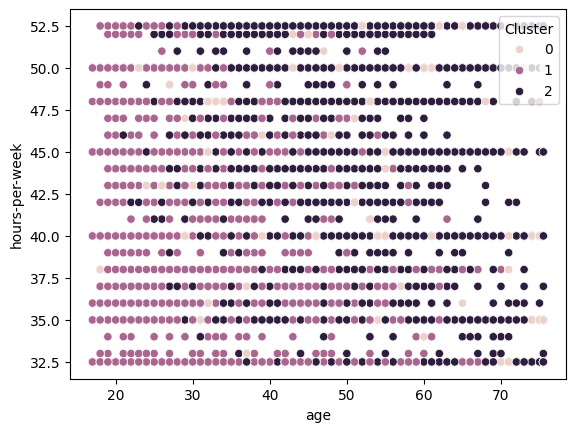

In [50]:
import seaborn as sns
sns.scatterplot(x="age",y="hours-per-week",hue="Cluster",data=df)

In [51]:
#df.select_dtypes(include=['float64', 'int64']).columns
numeric_cols = [
    "age", "fnlwgt", "education-num", "hours-per-week",
    "log_capital-gain", "log_capital-loss"
]

categorical_cols = [
    "workclass", "education", "marital-status", "occupation",
    "relationship", "race", "sex", "native-country"
]

# Mean for numeric
numeric_summary = df.groupby("Cluster")[numeric_cols].mean()

# Mode for categorical
categorical_summary = df.groupby("Cluster")[categorical_cols].count()

cluster_summary = pd.concat([numeric_summary, categorical_summary], axis=1)
cluster_summary


,age,fnlwgt,education-num,hours-per-week,log_capital-gain,log_capital-loss,workclass,education,marital-status,occupation,relationship,race,sex,native-country
Cluster,,,,,,,,,,,,,,
0,41.594873,186031.904032,11.006573,42.641104,0.000000,7.511927,2282,2282,2282,2282,2282,2282,2282,2282
1,31.847395,194840.032912,9.641106,38.902742,0.122831,0.000000,23741,23741,23741,23741,23741,23741,23741,23741
2,45.196552,178413.509126,10.535098,43.300487,1.433222,0.000000,22793,22793,22793,22793,22793,22793,22793,22793


In [52]:
import numpy as np
print(np.isnan(X_scaled).sum())


0


Hierarchical Clustering

In [53]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

# Perform hierarchical clustering
Z = linkage(X_scaled, method='single')

import numpy as np

n = X_scaled.shape[0]
print("Max index in Z:", np.max(Z[:, :2]))
print("Allowed max index:", n + (n - 2))


Max index in Z: 97629.0
Allowed max index: 97630


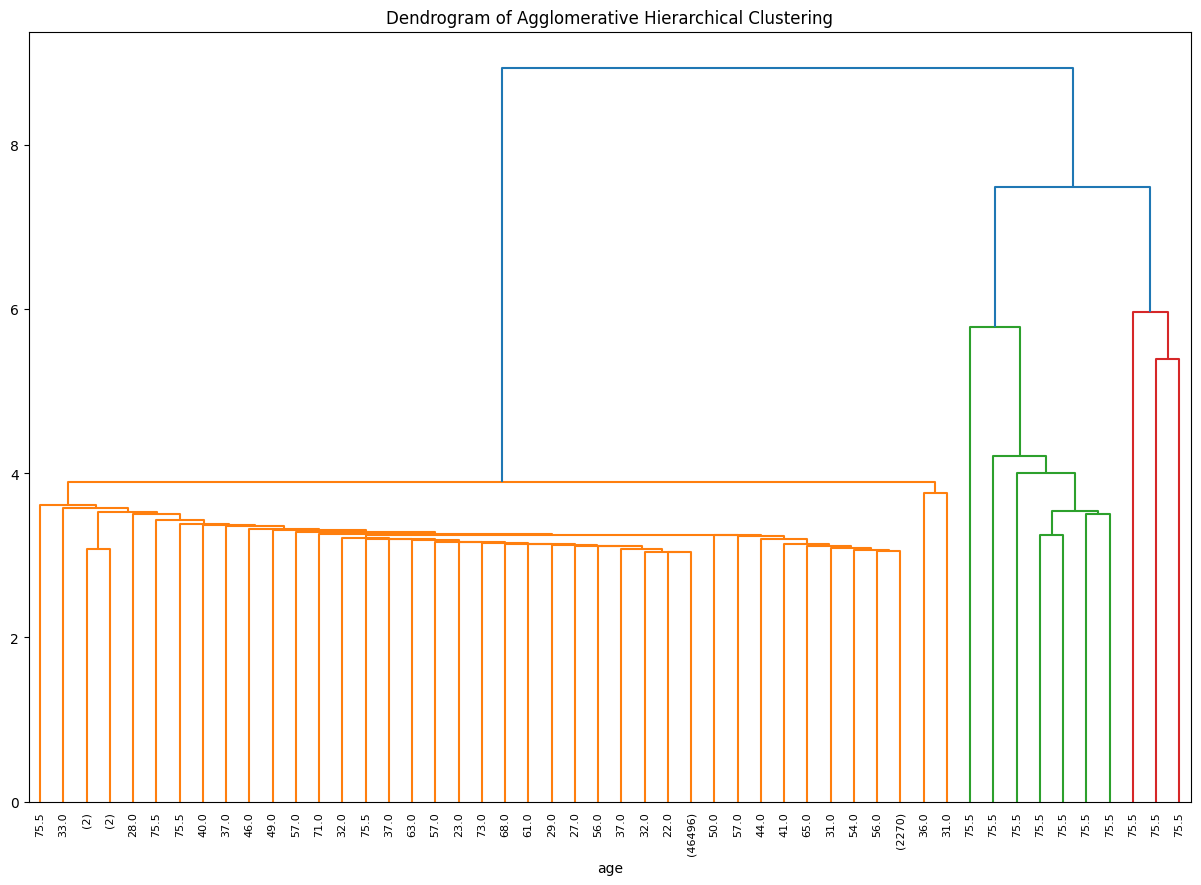

In [54]:
plt.figure(figsize=(15, 10))
dendrogram(
    Z,labels=df['age'].tolist(),
    truncate_mode='lastp',
    p=50,
    leaf_rotation=90,
    show_leaf_counts=True
)
plt.title('Dendrogram of Agglomerative Hierarchical Clustering')
plt.xlabel('age')
plt.show()


In [55]:
from sklearn.cluster import KMeans, AgglomerativeClustering #hirearchy
 #bottom up technique
# Example with 3 clusters
hc = AgglomerativeClustering(n_clusters=3,linkage="single")

# Fit and predict clusters
df['Cluster'] = hc.fit_predict(X_scaled)

df.head()

/tmp/ipython-input-2112662033.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Cluster'] = hc.fit_predict(X_scaled)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,hours-per-week,native-country,log_capital-gain,log_capital-loss,Cluster
0,39.0,State-gov,77516.0,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,40.0,United-States,7.684784,0.0,1
1,50.0,Self-emp-not-inc,83311.0,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,32.5,United-States,0.000000,0.0,1
2,38.0,Private,215646.0,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,40.0,United-States,0.000000,0.0,1
3,53.0,Private,234721.0,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,40.0,United-States,0.000000,0.0,1
4,28.0,Private,338409.0,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,40.0,Cuba,0.000000,0.0,1


In [56]:
#Evaluate Clustering

# Silhouette Score: Measure how well the clusters are separated.

from sklearn.metrics import silhouette_score
labels = hc.labels_
silhouette_avg = silhouette_score(X_scaled, labels)

print(silhouette_avg)

0.7277415116728091


<Axes: xlabel='age', ylabel='hours-per-week'>

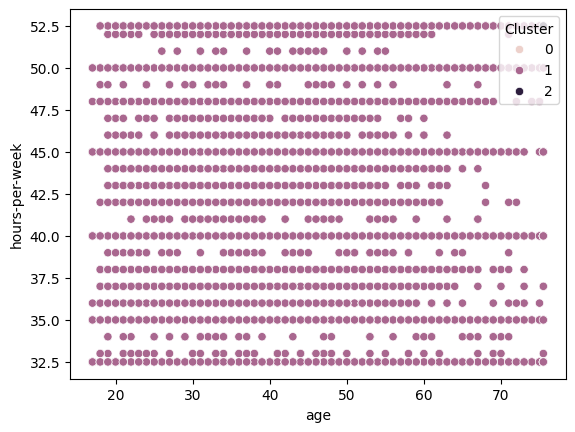

In [57]:
import seaborn as sns
sns.scatterplot(x="age",y="hours-per-week",hue="Cluster",data=df)

In [58]:
numeric_cols = [
    "age", "fnlwgt", "education-num", "hours-per-week",
    "log_capital-gain", "log_capital-loss"
]

categorical_cols = [
    "workclass", "education", "marital-status", "occupation",
    "relationship", "race", "sex", "native-country"
]

# Mean for numeric
numeric_summary = df.groupby("Cluster")[numeric_cols].mean()

# Mode for categorical
categorical_summary = df.groupby("Cluster")[categorical_cols].count()

cluster_summary = pd.concat([numeric_summary, categorical_summary], axis=1)
cluster_summary


,age,fnlwgt,education-num,hours-per-week,log_capital-gain,log_capital-loss,workclass,education,marital-status,occupation,relationship,race,sex,native-country
Cluster,,,,,,,,,,,,,,
0,75.500000,205801.791667,10.333333,52.50000,0.000000,0.000000,3,3,3,3,3,3,3,3
1,38.528429,186757.594036,10.122464,41.12855,0.729082,0.351076,48806,48806,48806,48806,48806,48806,48806,48806
2,75.500000,184657.142857,9.285714,52.50000,0.000000,1.086057,7,7,7,7,7,7,7,7


In [59]:
X_scaled

array([[ 0.02944206, -1.06185811,  1.13660915, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.83812135, -1.00698516,  1.13660915, ...,  1.        ,
         0.        ,  0.        ],
       [-0.04407424,  0.24609701, -0.41960057, ...,  1.        ,
         0.        ,  0.        ],
       ...,
       [-0.04407424,  1.75486155,  1.13660915, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.39702356, -1.00149314,  1.13660915, ...,  1.        ,
         0.        ,  0.        ],
       [-0.26462314, -0.07109607,  1.13660915, ...,  1.        ,
         0.        ,  0.        ]])

DBSCAN

In [61]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1. Apply PCA on scaled data
# -----------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]

# Explained variance
expl_var = pca.explained_variance_ratio_
print("Explained Variance Ratio:")
print(f"PC1: {expl_var[0]:.4f}")
print(f"PC2: {expl_var[1]:.4f}")
print(f"Total (PC1 + PC2): {expl_var.sum():.4f}")



Explained Variance Ratio:
PC1: 0.1520
PC2: 0.1075
Total (PC1 + PC2): 0.2595


/tmp/ipython-input-4240409571.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['PC1'] = X_pca[:, 0]
/tmp/ipython-input-4240409571.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['PC2'] = X_pca[:, 1]


PC1 + PC2 explain ~26% of the total variance

In [63]:
print(df.columns)


Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'hours-per-week', 'native-country', 'log_capital-gain',
       'log_capital-loss', 'Cluster', 'PC1', 'PC2'],
      dtype='object')


In [64]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
df["KMeans_Label"] = kmeans.fit_predict(X_scaled)


/tmp/ipython-input-3647866307.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["KMeans_Label"] = kmeans.fit_predict(X_scaled)


In [65]:
df.rename(columns={"Cluster": "Agglomerative_Label"}, inplace=True)


/tmp/ipython-input-1931202079.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={"Cluster": "Agglomerative_Label"}, inplace=True)


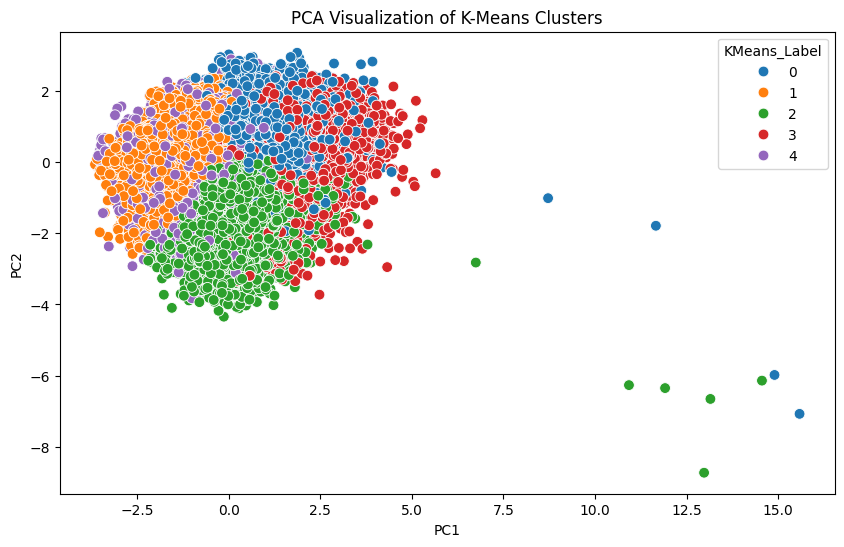

In [66]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='PC1',
    y='PC2',
    hue='KMeans_Label',
    palette='tab10',
    s=60
)
plt.title("PCA Visualization of K-Means Clusters")
plt.show()


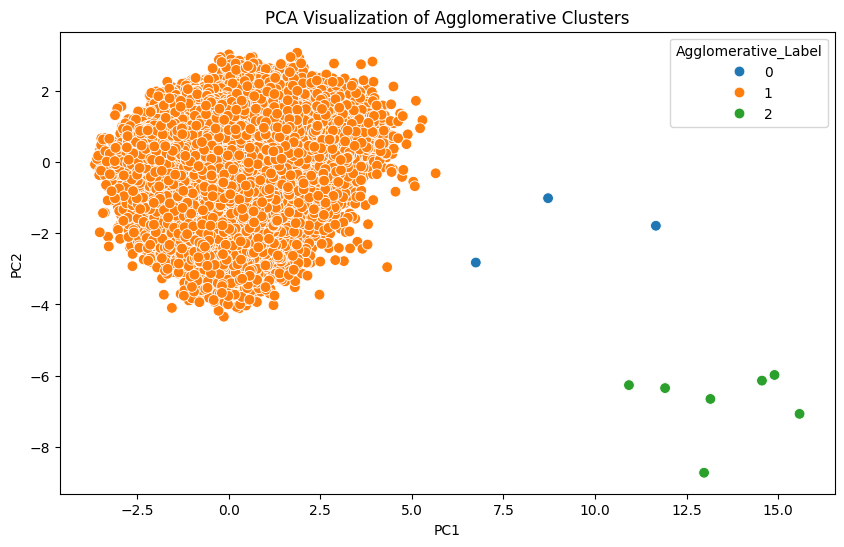

In [67]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='PC1',
    y='PC2',
    hue='Agglomerative_Label',
    palette='tab10',
    s=60
)
plt.title("PCA Visualization of Agglomerative Clusters")
plt.show()


In [ ]:
df=df.drop_duplicates()

In [ ]:
plt.figure()

# Noise points
noise = df[df["DBSCAN_Label"] == -1]
plt.scatter(noise["mean radius"], noise["mean texture"],
            label="Noise (Outliers)")

# Clustered points
clusters = df[df["DBSCAN_Label"] != -1]
plt.scatter(clusters["mean radius"], clusters["mean texture"],
            label="Clustered Points")

plt.xlabel("Mean Radius")
plt.ylabel("Mean Texture")
plt.title("DBSCAN Density-Based Outliers")

plt.legend()
plt.show()


In [ ]:
# Plot the dendrogram
plt.figure(figsize=(15, 10))
dendrogram(Z, labels=df['age'].tolist(), leaf_rotation=90)
plt.title('Dendrogram of Agglomerative Hierarchical Clustering')
plt.xlabel('age')
plt.ylabel('hours-per-week')
plt.show()


In [ ]:
from scipy.cluster.hierarchy import linkage

Z = linkage(X_scaled, method='single')


In [ ]:
import numpy as np

n = X_scaled.shape[0]
print("Max index in Z:", np.max(Z[:, :2]))
print("Allowed max index:", n + (n - 2))


In [ ]:
plt.figure(figsize=(10, 7))
dendrogram = sch.dendrogram(sch.linkage(X_sample[:1000], method='ward'))
plt.title('Dendrogram'); plt.show()

In [ ]:
# 5. Clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# FIX: Pass the matrix X_scaled here, not a column name string
df['Cluster'] = kmeans.fit_predict(X_scaled)

# View the result
print(df[['age', 'workclass', 'education', 'Cluster']].head())

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
# Encoding & Scaling

preprocess = ColumnTransformer([
    #df_clustering = df.drop('income', axis=1)
    ('num', StandardScaler(), num_cols1),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols1)
])

#Generate the scaled numerical matrix
X_scaled = preprocess.fit_transform(df_clustering)

# 5. Clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# FIX: Pass the matrix X_scaled here, not a column name string
df['Cluster'] = kmeans.fit_predict(X_scaled)

# View the result
print(df[['age', 'workclass', 'education', 'Cluster']].head())

In [ ]:
df

In [ ]:
# --- EXPLORATORY DATA ANALYSIS (EDA) ---
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); sns.histplot(df['age'], kde=True); plt.title('Age Distribution')
plt.subplot(1, 3, 2); sns.histplot(df['hours-per-week'], kde=True); plt.title('Hours/Week')
plt.subplot(1, 3, 3); df['education'].value_counts().plot(kind='bar'); plt.title('Education')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
# 2. Clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict('X_scaled')


In [ ]:
sns.scatterplot(x=df['age'], y=df['hours-per-week'], hue=df['Cluster'],palette='summer')
plt.title('working hours vs age')
plt.show()

elbow method

In [ ]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(X_scaled)

In [ ]:
 3. PCA Visualization
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=pca_data[:, 0], y=pca_data[:, 1], hue=labels_km, palette='viridis')
plt.title('Workforce Segments Visualization (PCA)')
plt.show()